## GNN and HGNN Comparison
### Data is from the shared Thesis Drive

### Setup

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive/Thesis "  # trailing space is intentional

with open(f"{DRIVE_DIR}/baseline_results.json") as f:
    baseline = json.load(f)
with open(f"{DRIVE_DIR}/hgnn_vmn_results.json") as f:
    hgnn = json.load(f)

# Bands to plot (drop dist == 0, n=1 isn't meaningful)
BANDS = ["dist == 1", "dist == 2", "dist == 3", "dist == 4", "dist >= 5"]
BAND_LABELS = ["1", "2", "3", "4", "≥5"]


def extract(results, key):
    """Pull a column from the per_band rows in the order of BANDS."""
    by_band = {row["band"]: row for row in results["per_band"]}
    return np.array([by_band[b][key] for b in BANDS])


b_mean = extract(baseline, "mean_mse")
b_std = extract(baseline, "std_mse")
b_n_seeds = len(baseline["seeds"])

h_mean = extract(hgnn, "mean_mse")
h_std = extract(hgnn, "std_mse")
h_n_seeds = len(hgnn["seeds"])

# Number of nodes per band (for reporting, not for CIs)
ns = extract(baseline, "n").astype(int)

# 95% CI half-width on the mean: 1.96 * std / sqrt(n_seeds)
b_ci = 1.96 * b_std / np.sqrt(b_n_seeds)
h_ci = 1.96 * h_std / np.sqrt(h_n_seeds)

print(f"Baseline: {b_n_seeds} seeds | HGNN: {h_n_seeds} seeds\n")
print(f"{'band':<8s}  {'baseline mean':>15s}  {'95% CI':>12s}  "
      f"{'HGNN mean':>12s}  {'95% CI':>12s}")
for i, b in enumerate(BAND_LABELS):
    print(f"dist {b:<3s}  {b_mean[i]:>15,.0f}  ±{b_ci[i]:>10,.0f}  "
          f"{h_mean[i]:>12,.0f}  ±{h_ci[i]:>10,.0f}")


Mounted at /content/drive
Baseline: 100 seeds | HGNN: 100 seeds

band        baseline mean        95% CI     HGNN mean        95% CI
dist 1             16,808  ±     1,152        14,808  ±       934
dist 2             90,056  ±     3,204        56,115  ±     2,483
dist 3            194,509  ±     6,347        95,359  ±     4,493
dist 4            207,113  ±     9,828        77,806  ±     4,278
dist ≥5           326,334  ±    15,509        62,993  ±     3,974


### Style

In [ ]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",  # safe in Colab; swap for "Helvetica" locally
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

C_BASELINE = "#888780"   # neutral gray
C_HGNN = "#534AB7"       # purple
C_THRESHOLD = "#993C1D"  # muted coral for the noise threshold



### MSE

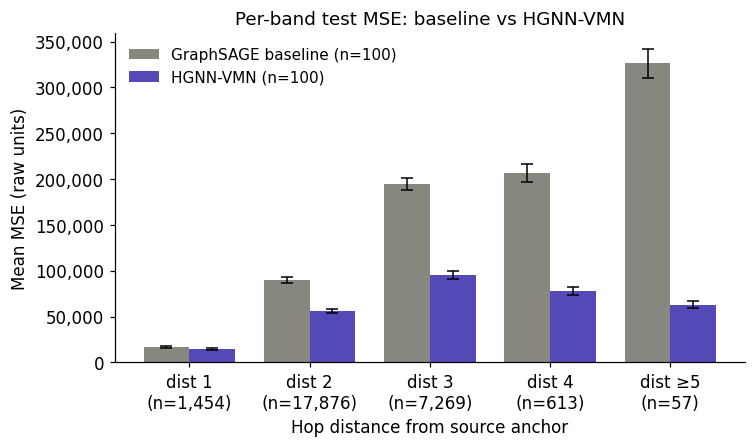

In [ ]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))

x = np.arange(len(BAND_LABELS))
w = 0.38

ax.bar(x - w/2, b_mean, w, yerr=b_ci, capsize=4,
       color=C_BASELINE, label=f"GraphSAGE baseline (n={b_n_seeds})",
       error_kw={"elinewidth": 1.0, "ecolor": "black"})
ax.bar(x + w/2, h_mean, w, yerr=h_ci, capsize=4,
       color=C_HGNN, label=f"HGNN-VMN (n={h_n_seeds})",
       error_kw={"elinewidth": 1.0, "ecolor": "black"})

ax.set_xticks(x)
ax.set_xticklabels([f"dist {b}\n(n={ns[i]:,})" for i, b in enumerate(BAND_LABELS)])
ax.set_xlabel("Hop distance from source anchor")
ax.set_ylabel("Mean MSE (raw units)")
ax.set_title("Per-band test MSE: baseline vs HGNN-VMN")
ax.legend(loc="upper left")

# Add y-axis comma formatting
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v:,.0f}")
)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fig1_per_band_mse.pdf")
plt.savefig(f"{DRIVE_DIR}/fig1_per_band_mse.png")
plt.show()



# Effect Size

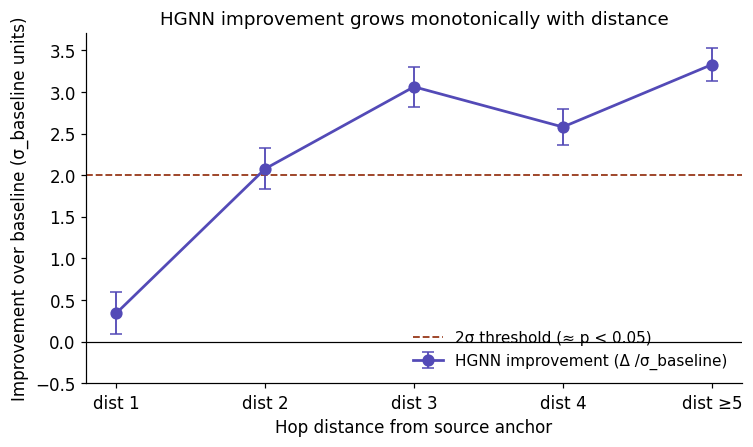

In [ ]:
delta = b_mean - h_mean              # positive = HGNN better
delta_sigma = delta / b_std          # in baseline-σ units

# Confidence interval on Δ (treating both samples as independent):
# σ_diff = sqrt(σ_b²/n_b + σ_h²/n_h), then divide by σ_b to keep σ-units.
delta_se = np.sqrt(b_std**2 / b_n_seeds + h_std**2 / h_n_seeds)
delta_sigma_ci = 1.96 * delta_se / b_std

fig, ax = plt.subplots(figsize=(7.0, 4.2))

ax.errorbar(x, delta_sigma, yerr=delta_sigma_ci,
            fmt="o-", color=C_HGNN, ecolor=C_HGNN,
            elinewidth=1.2, capsize=4, markersize=7, linewidth=1.8,
            label="HGNN improvement (Δ /σ_baseline)")

ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(2, color=C_THRESHOLD, linewidth=1.2, linestyle="--",
           label="2σ threshold (≈ p < 0.05)")

ax.set_xticks(x)
ax.set_xticklabels([f"dist {b}" for b in BAND_LABELS])
ax.set_xlabel("Hop distance from source anchor")
ax.set_ylabel("Improvement over baseline (σ_baseline units)")
ax.set_title("HGNN improvement grows monotonically with distance")
ax.legend(loc="lower right")
ax.set_ylim(bottom=min(-0.5, delta_sigma.min() - 0.5))

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fig2_effect_size.pdf")
plt.savefig(f"{DRIVE_DIR}/fig2_effect_size.png")
plt.show()


## Variance Reduction

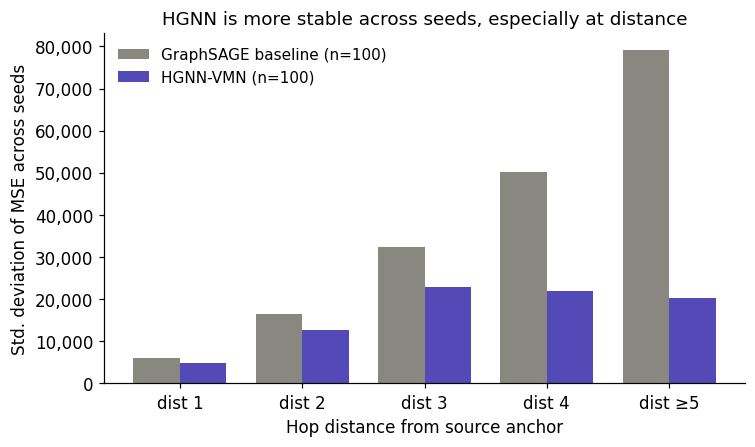

In [ ]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))

ax.bar(x - w/2, b_std, w, color=C_BASELINE,
       label=f"GraphSAGE baseline (n={b_n_seeds})")
ax.bar(x + w/2, h_std, w, color=C_HGNN,
       label=f"HGNN-VMN (n={h_n_seeds})")

ax.set_xticks(x)
ax.set_xticklabels([f"dist {b}" for b in BAND_LABELS])
ax.set_xlabel("Hop distance from source anchor")
ax.set_ylabel("Std. deviation of MSE across seeds")
ax.set_title("HGNN is more stable across seeds, especially at distance")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v:,.0f}")
)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fig3_variance.pdf")
plt.savefig(f"{DRIVE_DIR}/fig3_variance.png")
plt.show()



### Summary

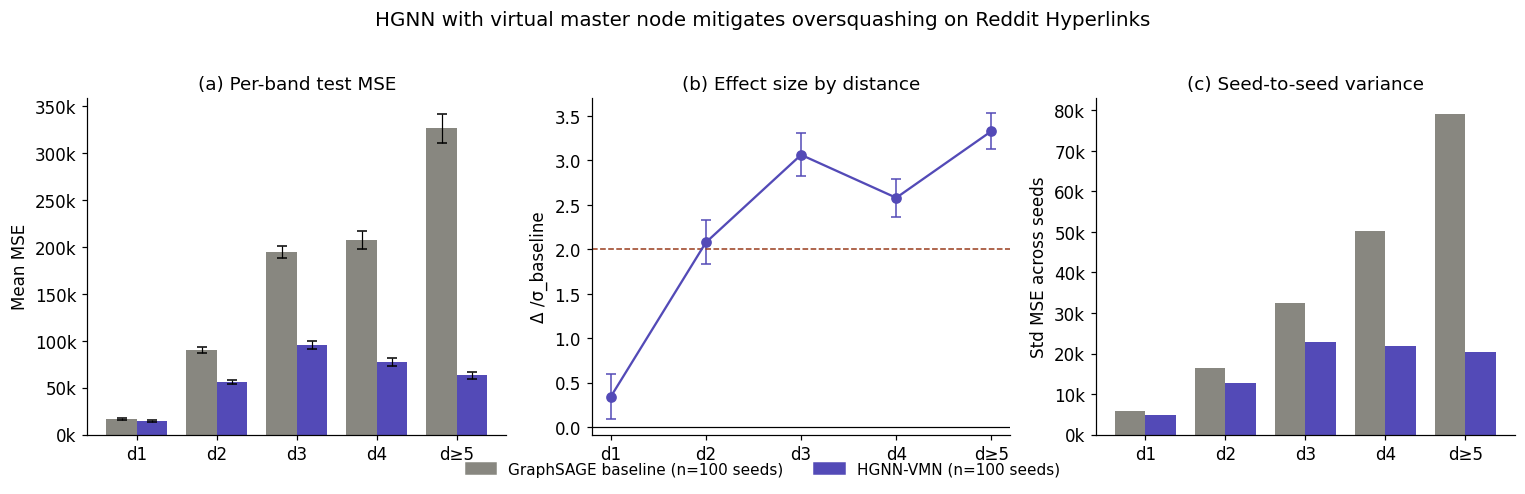


Saved to Drive:
  fig1_per_band_mse.{pdf,png}
  fig2_effect_size.{pdf,png}
  fig3_variance.{pdf,png}
  fig4_summary.{pdf,png}


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Panel A: mean MSE
ax = axes[0]
ax.bar(x - w/2, b_mean, w, yerr=b_ci, capsize=3,
       color=C_BASELINE, error_kw={"elinewidth": 0.8, "ecolor": "black"})
ax.bar(x + w/2, h_mean, w, yerr=h_ci, capsize=3,
       color=C_HGNN, error_kw={"elinewidth": 0.8, "ecolor": "black"})
ax.set_xticks(x)
ax.set_xticklabels([f"d{b}" for b in BAND_LABELS])
ax.set_ylabel("Mean MSE")
ax.set_title("(a) Per-band test MSE")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))

# Panel B: effect size
ax = axes[1]
ax.errorbar(x, delta_sigma, yerr=delta_sigma_ci,
            fmt="o-", color=C_HGNN, ecolor=C_HGNN,
            elinewidth=1.0, capsize=3, markersize=6)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(2, color=C_THRESHOLD, linewidth=1.0, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels([f"d{b}" for b in BAND_LABELS])
ax.set_ylabel("Δ /σ_baseline")
ax.set_title("(b) Effect size by distance")

# Panel C: std
ax = axes[2]
ax.bar(x - w/2, b_std, w, color=C_BASELINE)
ax.bar(x + w/2, h_std, w, color=C_HGNN)
ax.set_xticks(x)
ax.set_xticklabels([f"d{b}" for b in BAND_LABELS])
ax.set_ylabel("Std MSE across seeds")
ax.set_title("(c) Seed-to-seed variance")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))

# Shared legend below
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=C_BASELINE, label=f"GraphSAGE baseline (n={b_n_seeds} seeds)"),
        plt.Rectangle((0, 0), 1, 1, color=C_HGNN, label=f"HGNN-VMN (n={h_n_seeds} seeds)"),
    ],
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.02),
)

plt.suptitle("HGNN with virtual master node mitigates oversquashing on Reddit Hyperlinks",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fig4_summary.pdf")
plt.savefig(f"{DRIVE_DIR}/fig4_summary.png")
plt.show()

print("\nSaved to Drive:")
print("  fig1_per_band_mse.{pdf,png}")
print("  fig2_effect_size.{pdf,png}")
print("  fig3_variance.{pdf,png}")
print("  fig4_summary.{pdf,png}")
